In [1]:
import sys,os
sys.path.append(os.getcwd() + '/..')

import torch
import pandas as pd
import os
import numpy as np
import cv2
from skimage.morphology import disk
from skimage.filters import rank
from tqdm import tqdm
from multiprocessing import Pool
from common.preprocessing import Equalize
import matplotlib.pyplot as plt
import math

In [15]:
PATCH_SIZE = 256
IMG_SIZE = 2560
from common.bounding_boxes import *
patch_bbs = patches_bbs_for_image(IMG_SIZE, PATCH_SIZE, stride=PATCH_SIZE//2)

eq = Equalize("../common/data/07_4001_3R1212_crop.rec.8bit.tif")


(2560, 2560) (2560, 2560)


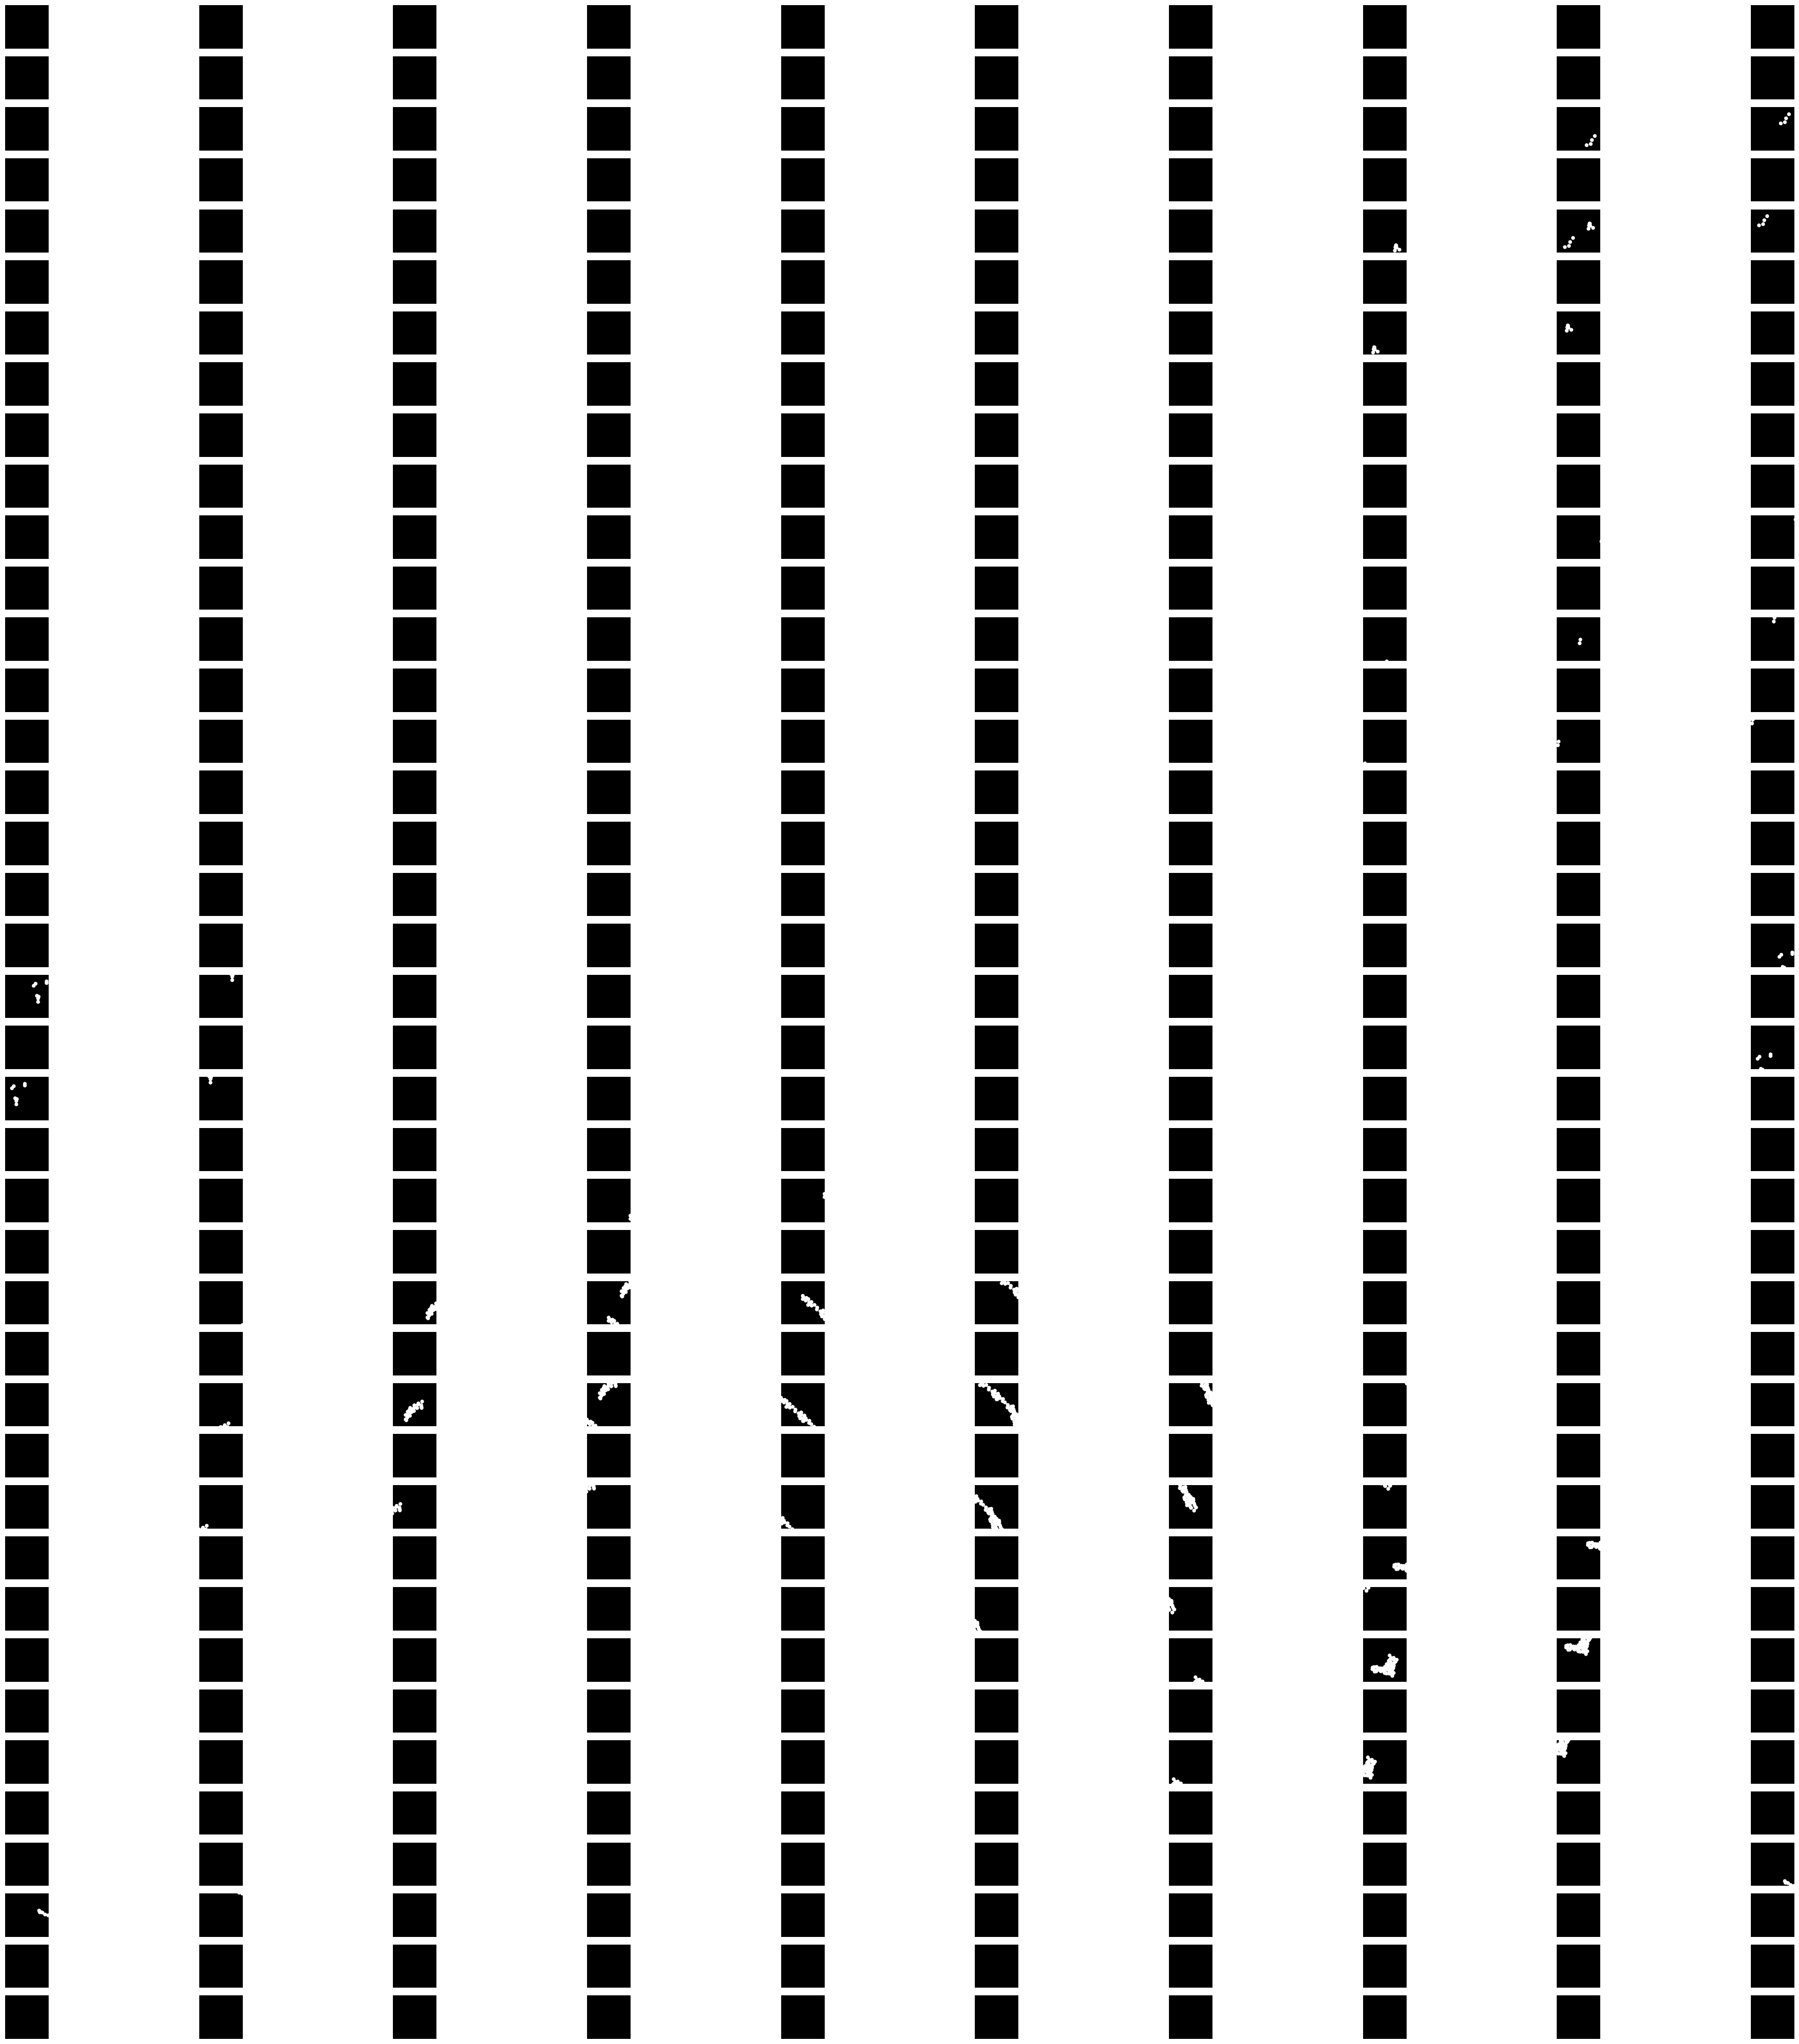

In [18]:
COLS = 10

df = pd.read_csv("../data/fresh/train.csv")
df1 = df[df['target'] == 2]
df1.groupby('type').count()
base = '/storage/home/dvrsnak/dataset_biopsies'
for i, row in df1.iterrows():
    if not row.isnull().mask_infiltrates:
        img = os.path.join(base, row.image)
        msk = os.path.join('../data/masks', row.mask_infiltrates + '.npy')
        image = cv2.imread(img, cv2.IMREAD_UNCHANGED)
        mask = np.load(msk)
        print(mask.shape, image.shape)
        patches, mask_patches = [], []
        for patch_bb in patch_bbs:
            x,y,w,h = patch_bb
            if x + w > image.shape[1] or y + h > image.shape[0]:
                x = image.shape[1] - w
                y = image.shape[0] - h
            patch = image[y:y+h, x:x+w]
            mask_patch = mask[y:y+h, x:x+w]
            if patch.shape[0] != PATCH_SIZE or patch.shape[1] != PATCH_SIZE:
                continue
            patches.append(patch)
            mask_patches.append(mask_patch)
        fig, ax = plt.subplots(math.ceil(len(patches)/COLS), ncols=COLS, figsize=(40, 40))
        for i, patch in enumerate(mask_patches):
            ax[i//COLS, i%COLS].imshow(patch, cmap='gray')
            ax[i//COLS, i%COLS].axis('off')
        plt.tight_layout()
        break